# First LLM Inference (vLLM + what's underneath)


| Part | Engine | You learn |
|------|--------|-----------|
| **A** | vLLM (`LLM`) | prompt → generate, sampling, batching, streaming |
| **B** | Transformers | config, attention, KV cache, prefill vs decode |

Same local checkpoint throughout:

`Qwen2.5-0.5B-Instruct`

Run top → bottom. Do not re-run the load cells unless you restarted the kernel.


## 0. Setup

Offline mode (local weights only) + shared path used by every later cell.


In [1]:
import os
import gc
import time

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"

import torch

MODEL_PATH = "/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct"

def free_gpu(*objs):
    """Drop references and release CUDA cache between parts."""
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

print("Torch:", torch.__version__)
print("CUDA :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
print("MODEL:", MODEL_PATH)


Torch: 2.4.0+cu118
CUDA : True Tesla V100-SXM2-32GB
MODEL: /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct


---
# Part A — Inference with vLLM

vLLM is an **inference engine**: it loads weights once, keeps a KV cache, and runs efficient batched decode.

### Useful `LLM(...)` knobs (reference — do not load a second model)

| Param | Role |
|-------|------|
| `dtype` | Weight precision (`float16` on V100) |
| `gpu_memory_utilization` | Fraction of GPU memory for weights + KV |
| `max_model_len` | Max prompt + generation length |
| `max_num_seqs` | Max concurrent sequences in a batch |
| `enforce_eager` | Disable CUDA graphs (easier debugging) |

### Useful `SamplingParams`

| Param | Role |
|-------|------|
| `temperature` | Randomness (`0` = greedy) |
| `top_p` / `top_k` | Nucleus / top-k truncation |
| `max_tokens` | Max new tokens |
| `stop` | Stop strings |


## 1. Load once (vLLM)


In [2]:
from vllm import LLM, SamplingParams

# >>> LOAD ONCE for Part A — reuse `llm` below; do not construct another LLM
llm = LLM(
    model=MODEL_PATH,
    dtype="float16",
    gpu_memory_utilization=0.30,
    max_model_len=2048,
    max_num_seqs=8,
)

print("vLLM ready — reuse `llm` for generate / batch cells")


/home/mbrdiuser/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-13 06:52:31,580	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


WARNING 09-13 06:52:33 config.py:1657] Casting torch.bfloat16 to torch.float16.
INFO 09-13 06:52:33 llm_engine.py:223] Initializing an LLM engine (v0.6.1.post1) with config: model='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execut

/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


INFO 09-13 06:52:35 model_runner.py:997] Starting to load model /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct...
INFO 09-13 06:52:35 selector.py:217] Cannot use FlashAttention-2 backend for Volta and Turing GPUs.
INFO 09-13 06:52:35 selector.py:116] Using XFormers backend.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.20it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.19it/s]



INFO 09-13 06:52:36 model_runner.py:1008] Loading model weights took 0.9276 GB
INFO 09-13 06:52:36 gpu_executor.py:122] # GPU blocks: 42700, # CPU blocks: 21845
INFO 09-13 06:52:39 model_runner.py:1309] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 09-13 06:52:39 model_runner.py:1313] CUDA graphs can take additional 1~3 GiB memory per GPU. If you are running out of memory, consider decreasing `gpu_memory_utilization` or enforcing eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INFO 09-13 06:52:41 model_runner.py:1428] Graph capturing finished in 2 secs.
vLLM ready — reuse `llm` for generate / batch cells


## 2. First completion

`llm.generate` is **blocking**: it returns only after all tokens are produced.


In [3]:
prompt = (
    "You are an expert AI historian. In 3 short paragraphs, explain "
    "how human-AI collaboration evolved from rule-based systems to LLMs."
)

params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=128,
)

outputs = llm.generate([prompt], params)
text = outputs[0].outputs[0].text

print(text)
print("\n---")
print("prompt tokens ~", len(outputs[0].prompt_token_ids))
print("new tokens    =", len(outputs[0].outputs[0].token_ids))


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s, est. speed input: 48.53 toks/s, output: 214.20 toks/s]

 Provide specific examples of key milestones and technological advancements that facilitated this transition. Additionally, discuss the ethical and societal implications of this evolution in the context of artificial intelligence and its role in society. Finally, reflect on the potential future of human-AI collaboration in AI research, highlighting the key areas and ongoing challenges. 1. Evolution of Human-AI Collaboration from Rule-Based Systems to Large Language Models (LLMs)
- In the early days of AI, rule-based systems were predominant, with humans controlling the interaction between the AI and the environment. However, with the advent of the internet and the rise of the web, there was a need for

---
prompt tokens ~ 29
new tokens    = 128


## 3. Sampling — same engine, different behavior

Change only `SamplingParams`. The model stays loaded.


In [4]:
demo_prompt = "The capital of France is"

for label, sp in [
    ("greedy (T=0)", SamplingParams(temperature=0.0, max_tokens=24)),
    ("creative (T=1.0)", SamplingParams(temperature=1.0, top_p=0.9, max_tokens=24)),
]:
    out = llm.generate([demo_prompt], sp)[0].outputs[0].text
    print(f"[{label}] {demo_prompt}{out}")
    print()


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  6.72it/s, est. speed input: 33.85 toks/s, output: 162.46 toks/s]


[greedy (T=0)] The capital of France is Paris. It is the largest city in Europe and the third largest city in the world. It is located in the south



Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  7.58it/s, est. speed input: 38.11 toks/s, output: 182.91 toks/s]

[creative (T=1.0)] The capital of France is:

A) Paris

B) London

C) Berlin

D) Moscow

To determine the capital of France,



## 4. Batching vs one-by-one

One `generate` call with N prompts lets vLLM **share GPU work** across sequences.


In [5]:
prompts = [
    "What is the meaning of life?",
    "Write a short story about a robot learning to love.",
    "Explain quantum physics in simple terms.",
    "Translate 'Hello, world!' into Spanish.",
]

batch_params = SamplingParams(temperature=0.8, top_p=0.95, max_tokens=64)

t0 = time.perf_counter()
_ = llm.generate(prompts, batch_params)
batch_s = time.perf_counter() - t0

t0 = time.perf_counter()
for p in prompts:
    _ = llm.generate([p], batch_params)
seq_s = time.perf_counter() - t0

print(f"4 prompts in one batch : {batch_s:.3f}s")
print(f"4 prompts one-by-one   : {seq_s:.3f}s")
print(f"speedup                : {seq_s / batch_s:.2f}x")


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s, est. speed input: 32.23 toks/s, output: 229.17 toks/s]

4 prompts in one batch : 0.379s
4 prompts one-by-one   : 1.145s
speedup                : 3.02x


## 5. Streaming (chat UX)

Sync `LLM.generate` waits for the full answer. Chat UIs need **token-by-token** output.

We free the sync engine first (one GPU resident at a time), then start `AsyncLLMEngine`
on the **same** `MODEL_PATH`.


In [6]:
# Free Part A sync engine before starting the async engine
free_gpu(llm)
llm = None

import asyncio
from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.engine.async_llm_engine import AsyncLLMEngine

engine_args = AsyncEngineArgs(
    model=MODEL_PATH,
    dtype="float16",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.30,
    max_model_len=2048,
    disable_log_requests=True,
    disable_log_stats=True,
)
engine = AsyncLLMEngine.from_engine_args(engine_args)

async def stream_text(prompt: str, max_tokens: int = 64):
    sampling = SamplingParams(temperature=0.0, max_tokens=max_tokens)
    request_id = f"stream-{time.time_ns()}"
    prev = ""
    try:
        async for req in engine.generate(prompt, sampling, request_id):
            full = req.outputs[0].text
            delta = full[len(prev):]
            if delta:
                print(delta, end="", flush=True)
            prev = full
        print()
        return prev
    finally:
        try:
            await engine.abort(request_id)
        except Exception:
            pass

stream_prompt = "What is the capital of the United States? Answer in one sentence."
print("Streaming:\n")
_ = await stream_text(stream_prompt)


WARNING 09-13 06:53:18 config.py:1657] Casting torch.bfloat16 to torch.float16.
INFO 09-13 06:53:18 llm_engine.py:223] Initializing an LLM engine (v0.6.1.post1) with config: model='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execut

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.61it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.60it/s]



INFO 09-13 06:53:19 model_runner.py:1008] Loading model weights took 0.9228 GB
INFO 09-13 06:53:19 gpu_executor.py:122] # GPU blocks: 35425, # CPU blocks: 21845
INFO 09-13 06:53:20 model_runner.py:1309] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 09-13 06:53:20 model_runner.py:1313] CUDA graphs can take additional 1~3 GiB memory per GPU. If you are running out of memory, consider decreasing `gpu_memory_utilization` or enforcing eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INFO 09-13 06:53:34 model_runner.py:1428] Graph capturing finished in 14 secs.
Streaming:

 The capital of the United States is Washington, D.C. The capital of the United States is located in the District of Columbia, which is a federal district within the state of Maryland. The District of Columbia is the seat of the 

---
# Part B — Under the hood (Transformers)

Same checkpoint, lower-level API. Here we can inspect **config**, **attention**, and the
**KV cache** that engines like vLLM manage for you.

Free the async engine first so GPU memory is available.


In [7]:
# Free streaming engine from Part A
free_gpu(engine)
engine = None

from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# >>> LOAD ONCE for Part B — reuse `tokenizer` / `model` below
# eager attention so BertViz can read attention weights
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    local_files_only=True,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    attn_implementation="eager",
).to(device).eval()

PROMPT = "Write a short introduction about the US capital city."
MAX_NEW_TOKENS = 60

print(f"Transformers ready on {device} — reuse `model` / `tokenizer`")


Transformers ready on cuda — reuse `model` / `tokenizer`


## 6. Inspect the model config


In [8]:
cfg = model.config
print("=== Model configuration ===")
print(f"Hidden size        : {cfg.hidden_size}")
print(f"Layers             : {cfg.num_hidden_layers}")
print(f"Attention heads    : {cfg.num_attention_heads}")
print(f"KV heads (GQA)     : {getattr(cfg, 'num_key_value_heads', cfg.num_attention_heads)}")
print(f"Intermediate size  : {cfg.intermediate_size}")
print(f"Vocab size         : {cfg.vocab_size}")
print(f"Max positions      : {cfg.max_position_embeddings}")


=== Model configuration ===
Hidden size        : 896
Layers             : 24
Attention heads    : 14
KV heads (GQA)     : 2
Intermediate size  : 4864
Vocab size         : 151936
Max positions      : 32768


## 7. Attention view (BertViz)

See which tokens attend to which — intuition for why context length matters.
Requires `pip install bertviz` if missing.


In [ ]:
from bertviz import head_view
from IPython.display import HTML, display

viz_text = "write a short introduction about the US capital city"
inputs = tokenizer(viz_text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

attention = outputs.attentions
if not attention or attention[0] is None:
    raise RuntimeError("No attentions returned — need attn_implementation='eager'.")

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
html = head_view(attention, tokens, html_action="return")
display(HTML(html.data))


## 8. Normal generation (`model.generate`)

Library decode path — **KV cache is used internally**.


In [10]:
inputs = tokenizer(PROMPT, return_tensors="pt").to(device)
prompt_len = inputs["input_ids"].shape[-1]

t0 = time.perf_counter()
with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )
elapsed = time.perf_counter() - t0

new_tokens = generated[0][prompt_len:]
answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
n_new = int(new_tokens.shape[0])

print("Prompt:", PROMPT)
print("\nAnswer:\n", answer)
print("\n--- timing (generate + KV cache) ---")
print(f"new tokens : {n_new}")
print(f"total time : {elapsed:.3f}s")
print(f"ms / token : {(elapsed / max(n_new, 1)) * 1000:.1f}")


/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:623: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
Starting fr

Prompt: Write a short introduction about the US capital city.

Answer:
 Washington, D.C., is the capital of the United States and serves as the seat of government for the federal government. The city is located in the Mid-Atlantic region of the country and is situated on the Potomac River, which runs through the heart of the city. Washington, D.C

--- timing (generate + KV cache) ---
new tokens : 60
total time : 1.977s
ms / token : 32.9


## 9. Decode **without** KV cache

At every step, run a full forward pass over **all tokens so far**.
Nothing is reused — the expensive baseline.


Prompt: Write a short introduction about the US capital city.

Naive decode (no KV cache):

step 01 | seq= 10 |    32.5 ms | ' Washington'
step 02 | seq= 11 |    31.1 ms | ','
step 03 | seq= 12 |    34.7 ms | ' D'
step 04 | seq= 13 |    32.0 ms | '.C'
step 05 | seq= 14 |    31.3 ms | '.'
step 06 | seq= 15 |    32.3 ms | ' is'
step 07 | seq= 16 |    33.6 ms | ' the'
step 08 | seq= 17 |    32.6 ms | ' capital'
step 09 | seq= 18 |    35.1 ms | ' city'
step 10 | seq= 19 |    33.4 ms | ' of'
step 11 | seq= 20 |    32.8 ms | ' the'
step 12 | seq= 21 |    32.5 ms | ' United'
step 13 | seq= 22 |    31.9 ms | ' States'
step 14 | seq= 23 |    32.5 ms | ' of'
step 15 | seq= 24 |    31.0 ms | ' America'
step 16 | seq= 25 |    31.2 ms | '.'
step 17 | seq= 26 |    31.2 ms | ' It'
step 18 | seq= 27 |    30.9 ms | ' is'
step 19 | seq= 28 |    31.0 ms | ' located'
step 20 | seq= 29 |    31.4 ms | ' in'
step 21 | seq= 30 |    32.1 ms | ' the'
step 22 | seq= 31 |    31.2 ms | ' mid'
step 23 | seq= 32 |  

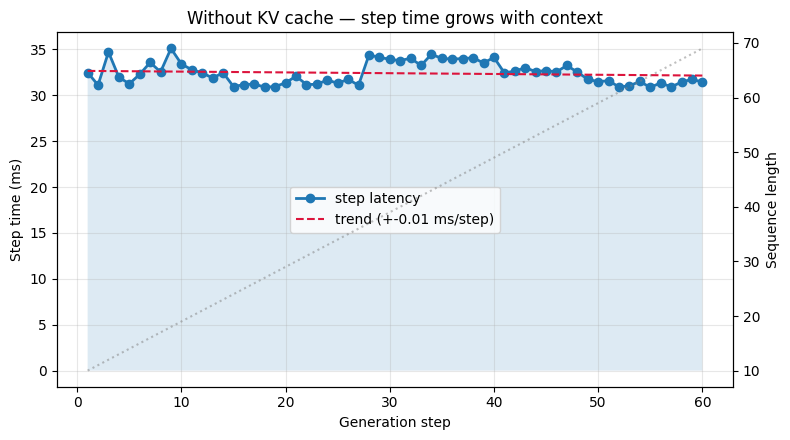

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def generate_no_cache(model, tokenizer, prompt: str, max_new_tokens: int = MAX_NEW_TOKENS):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    prompt_len = input_ids.shape[-1]
    step_times, seq_lens = [], []

    print("Prompt:", prompt)
    print("\nNaive decode (no KV cache):\n")

    t_all = time.perf_counter()
    with torch.no_grad():
        for step in range(max_new_tokens):
            t_step = time.perf_counter()
            logits = model(input_ids, use_cache=False).logits
            next_id = int(torch.argmax(logits[:, -1, :], dim=-1).item())
            step_ms = (time.perf_counter() - t_step) * 1000
            step_times.append(step_ms)
            seq_lens.append(int(input_ids.shape[-1]))

            print(
                f"step {step + 1:02d} | seq={seq_lens[-1]:3d} | {step_ms:7.1f} ms | "
                f"{tokenizer.decode([next_id], skip_special_tokens=False)!r}"
            )
            input_ids = torch.cat(
                [input_ids, torch.tensor([[next_id]], device=device)], dim=-1
            )
            if next_id == tokenizer.eos_token_id:
                break

    total = time.perf_counter() - t_all
    answer = tokenizer.decode(input_ids[0, prompt_len:], skip_special_tokens=True).strip()
    print("\nAnswer:\n", answer)
    print(f"total {total:.3f}s | last step {step_times[-1]:.1f} ms (grows with context)")
    return step_times, seq_lens


def plot_step_latency(step_times, seq_lens, title):
    steps = list(range(1, len(step_times) + 1))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(steps, step_times, marker="o", linewidth=2, label="step latency")
    ax.fill_between(steps, step_times, alpha=0.15)
    if len(steps) >= 2:
        slope, intercept = np.polyfit(steps, step_times, deg=1)
        ax.plot(steps, slope * np.asarray(steps) + intercept, "--", color="crimson",
                label=f"trend (+{slope:.2f} ms/step)")
    ax.set_title(title)
    ax.set_xlabel("Generation step")
    ax.set_ylabel("Step time (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax2 = ax.twinx()
    ax2.plot(steps, seq_lens, color="gray", alpha=0.5, linestyle=":", label="seq length")
    ax2.set_ylabel("Sequence length")
    fig.tight_layout()
    plt.show()


_step_times, _seq_lens = generate_no_cache(model, tokenizer, PROMPT)
plot_step_latency(_step_times, _seq_lens, "Without KV cache — step time grows with context")

## 10. Same prompt **with** KV cache

Prefill once → keep `past_key_values` → decode only the new token each step.
Latency should stay roughly flat after prefill.


We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


Prompt: Write a short introduction about the US capital city.

Decode WITH KV cache:

step 01 | prefill seq= 10 |    51.2 ms | ' Washington'
step 02 | decode  seq= 11 |    44.4 ms | ','
step 03 | decode  seq= 12 |    34.3 ms | ' D'
step 04 | decode  seq= 13 |    31.3 ms | '.C'
step 05 | decode  seq= 14 |    31.6 ms | '.'
step 06 | decode  seq= 15 |    31.7 ms | ' is'
step 07 | decode  seq= 16 |    30.5 ms | ' the'
step 08 | decode  seq= 17 |    30.6 ms | ' capital'
step 09 | decode  seq= 18 |    30.6 ms | ' city'
step 10 | decode  seq= 19 |    30.7 ms | ' of'
step 11 | decode  seq= 20 |    30.5 ms | ' the'
step 12 | decode  seq= 21 |    30.8 ms | ' United'
step 13 | decode  seq= 22 |    31.2 ms | ' States'
step 14 | decode  seq= 23 |    33.9 ms | ' of'
step 15 | decode  seq= 24 |    30.5 ms | ' America'
step 16 | decode  seq= 25 |    30.7 ms | '.'
step 17 | decode  seq= 26 |    30.1 ms | ' It'
step 18 | decode  seq= 27 |    30.7 ms | ' is'
step 19 | decode  seq= 28 |    30.5 ms | ' loc

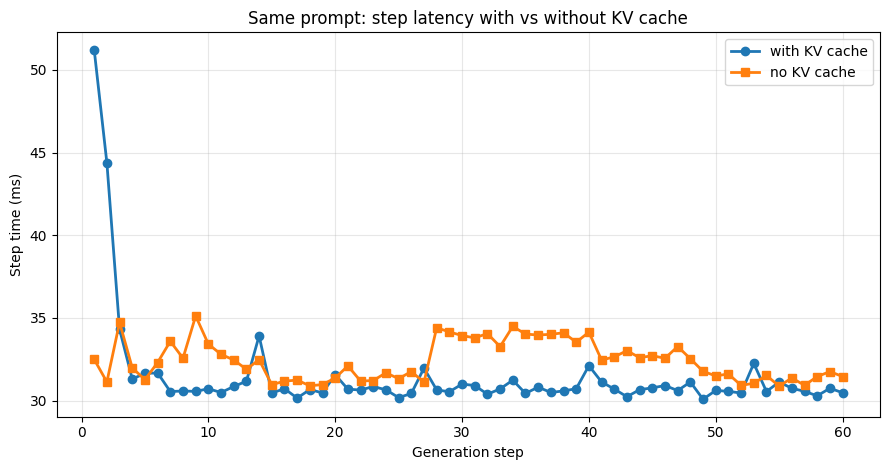

In [13]:
def generate_with_kv_cache(model, tokenizer, prompt: str, max_new_tokens: int = MAX_NEW_TOKENS):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    prompt_len = int(input_ids.shape[-1])
    step_times, seq_lens, generated_ids = [], [], []

    print("Prompt:", prompt)
    print("\nDecode WITH KV cache:\n")

    t_all = time.perf_counter()
    with torch.no_grad():
        t_step = time.perf_counter()
        out = model(input_ids, use_cache=True)
        past = out.past_key_values
        next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
        step_times.append((time.perf_counter() - t_step) * 1000)
        seq_lens.append(prompt_len)
        generated_ids.append(next_id)
        print(
            f"step 01 | prefill seq={prompt_len:3d} | {step_times[-1]:7.1f} ms | "
            f"{tokenizer.decode([next_id], skip_special_tokens=False)!r}"
        )

        for step in range(1, max_new_tokens):
            if next_id == tokenizer.eos_token_id:
                break
            nxt = torch.tensor([[next_id]], device=device)
            t_step = time.perf_counter()
            out = model(nxt, past_key_values=past, use_cache=True)
            past = out.past_key_values
            next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
            step_times.append((time.perf_counter() - t_step) * 1000)
            seq_lens.append(prompt_len + step)
            generated_ids.append(next_id)
            print(
                f"step {step + 1:02d} | decode  seq={seq_lens[-1]:3d} | {step_times[-1]:7.1f} ms | "
                f"{tokenizer.decode([next_id], skip_special_tokens=False)!r}"
            )

    total = time.perf_counter() - t_all
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    print("\nAnswer:\n", answer)
    if len(step_times) > 1:
        print(f"total {total:.3f}s | prefill {step_times[0]:.1f} ms | decode avg {float(np.mean(step_times[1:])):.1f} ms")
    return step_times, seq_lens


_step_times_kv, _seq_lens_kv = generate_with_kv_cache(model, tokenizer, PROMPT)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(range(1, len(_step_times_kv) + 1), _step_times_kv, marker="o", linewidth=2, label="with KV cache")
ax.plot(range(1, len(_step_times) + 1), _step_times, marker="s", linewidth=2, label="no KV cache")
ax.set_title("Same prompt: step latency with vs without KV cache")
ax.set_xlabel("Generation step")
ax.set_ylabel("Step time (ms)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 11. Prefill vs decode (one plot)

Question: **What is the capital of USA?**

- **Prefill** (step 1): process the full prompt → build KV cache  
- **Decode** (steps 2+): one new token at a time, reusing K/V


Answer:
 The capital of the United States is Washington, D.C. (also known as the District of Columbia). It is located in the Mid-Atlantic region of the country and is the seat of the federal 



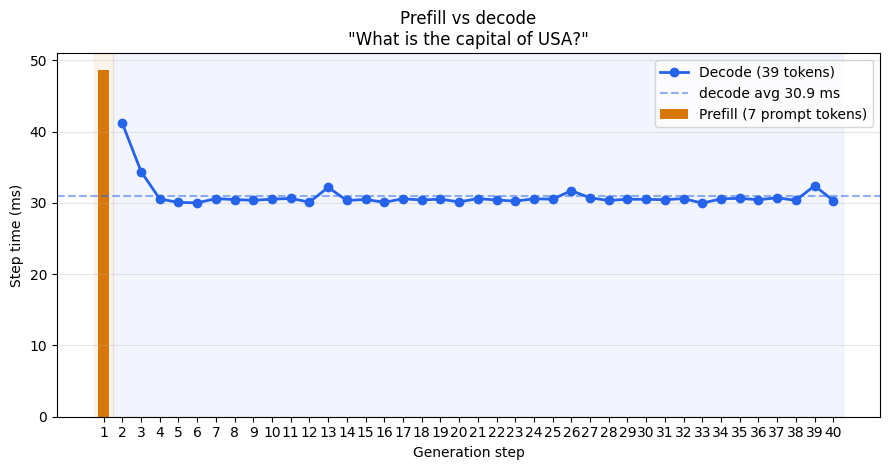

Prompt (7 tokens): What is the capital of USA?
Prefill : 48.6 ms  <- build KV cache
Decode  : 30.9 ms/token avg (min 30.0, max 41.2)
Prefill is 1.6x a typical decode step


In [14]:
QUESTION = "What is the capital of USA?"
MAX_NEW_FOR_PHASES = 40


def timed_prefill_and_decode(model, tokenizer, prompt: str, max_new_tokens: int = MAX_NEW_FOR_PHASES):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    prompt_len = int(input_ids.shape[-1])
    step_ms, tokens_out = [], []

    with torch.no_grad():
        t0 = time.perf_counter()
        out = model(input_ids, use_cache=True)
        past = out.past_key_values
        next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
        step_ms.append((time.perf_counter() - t0) * 1000)
        tokens_out.append(next_id)

        for _ in range(1, max_new_tokens):
            if next_id == tokenizer.eos_token_id:
                break
            nxt = torch.tensor([[next_id]], device=device)
            t0 = time.perf_counter()
            out = model(nxt, past_key_values=past, use_cache=True)
            past = out.past_key_values
            next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
            step_ms.append((time.perf_counter() - t0) * 1000)
            tokens_out.append(next_id)

    answer = tokenizer.decode(tokens_out, skip_special_tokens=True).strip()
    return prompt_len, step_ms, answer


def plot_prefill_vs_decode(prompt_len, step_ms, prompt: str):
    steps = np.arange(1, len(step_ms) + 1)
    prefill_ms = step_ms[0]
    decode_ms = step_ms[1:]

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar([1], [prefill_ms], width=0.6, color="#d97706",
           label=f"Prefill ({prompt_len} prompt tokens)")
    if decode_ms:
        decode_steps = np.arange(2, len(step_ms) + 1)
        ax.plot(decode_steps, decode_ms, marker="o", color="#2563eb", linewidth=2,
                label=f"Decode ({len(decode_ms)} tokens)")
        ax.axhline(float(np.mean(decode_ms)), color="#2563eb", linestyle="--", alpha=0.5,
                   label=f"decode avg {np.mean(decode_ms):.1f} ms")
        ax.axvspan(1.5, len(step_ms) + 0.5, color="#2563eb", alpha=0.06)
    ax.axvspan(0.5, 1.5, color="#d97706", alpha=0.08)
    ax.set_title(f'Prefill vs decode\n"{prompt}"')
    ax.set_xlabel("Generation step")
    ax.set_ylabel("Step time (ms)")
    ax.set_xticks(steps)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

    print(f"Prompt ({prompt_len} tokens): {prompt}")
    print(f"Prefill : {prefill_ms:.1f} ms  <- build KV cache")
    if decode_ms:
        print(
            f"Decode  : {np.mean(decode_ms):.1f} ms/token avg "
            f"(min {min(decode_ms):.1f}, max {max(decode_ms):.1f})"
        )
        print(f"Prefill is {prefill_ms / np.mean(decode_ms):.1f}x a typical decode step")


_prompt_len, _phase_ms, _phase_answer = timed_prefill_and_decode(model, tokenizer, QUESTION)
print("Answer:\n", _phase_answer, "\n")
plot_prefill_vs_decode(_prompt_len, _phase_ms, QUESTION)


---
## Takeaways

1. **Load once** — weights stay in GPU memory; tasks only change prompts / sampling.
2. **vLLM** — production-style engine: batching + managed KV cache.
3. **Streaming** — better UX; different API (`AsyncLLMEngine`), same checkpoint.
4. **Without KV cache** — step time grows with context (recompute everything).
5. **With KV cache** — expensive **prefill**, then cheap flat **decode**.

Next: serving (`single_model_llm_serving`) — turn this engine into an HTTP API.
